In [1]:
# Import pnecessary packages
import pandas as pd
from scipy.io import mmread
import scipy.sparse
import scanpy as sc
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ranksums
from scipy.stats import ttest_ind
from scipy.stats import mannwhitneyu
import os
import glob
import pandas as pd
import ast
import re
import numpy as np
from statannotations.Annotator import Annotator
import matplotlib.colors as mcolors
import anndata as ad

In [2]:
# Load preprocessed single cell data

# Main matrix
X = mmread("data/single_cell/GSE161824_A549_KRAS.processed.matrix.mtx").tocsr()
# Load gene names and barcodes
genes = pd.read_csv("data/single_cell/GSE161824_A549_KRAS.processed.genes.csv", header=None)
barcodes = pd.read_csv("data/single_cell/GSE161824_A549_KRAS.processed.cells.csv", header=None)

In [3]:
# Prepare anndata object
# Assign data
adata = ad.AnnData(X)
adata.var_names = genes[0].values  # column 1 = gene symbols
adata.obs_names = barcodes[0].values

# Calculate basic QC metrics
sc.pp.calculate_qc_metrics(adata, inplace=True)

# Filter cells: min genes, max counts, max % mitochondrial
adata = adata[adata.obs['n_genes_by_counts'] > 200, :]
adata = adata[adata.obs['total_counts'] < 25000, :]
sc.pp.filter_genes(adata, min_cells=10)

/nas/longleaf/rhel9/apps/anaconda/2024.02.ood/lib/python3.11/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
/nas/longleaf/rhel9/apps/anaconda/2024.02.ood/lib/python3.11/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
/nas/longleaf/home/kritis/.local/lib/python3.11/site-packages/scanpy/preprocessing/_simple.py:293: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  adata.var["n_cells"] = number


In [4]:
# List of genes in different categories
WT_list = pd.read_csv('data/KRAS_WT.csv')['cell'].tolist()
high_list = pd.read_csv('data/KRAS_highscore_clust0.csv')['cell'].tolist()
low_list = pd.read_csv('data/KRAS_lowscore_clust0.csv')['cell'].tolist()
otherKRAS_mut_list = pd.read_csv('data/KRAS_notclust0_mut.csv')['cell'].tolist()
other_mut_list = pd.read_csv('data/otherthanKRAS_mut.csv')['cell'].tolist()

In [5]:
# Mask anndata object based on categories
WT_mask = adata.obs_names.isin(WT_list)
gof_mask = adata.obs_names.isin(high_list)
lof_mask = adata.obs_names.isin(low_list)
otherKRAS_mask = adata.obs_names.isin(otherKRAS_mut_list)
othermut_mask = adata.obs_names.isin(other_mut_list)

# Apply the logic as a "mut" obs
adata.obs['mut'] = np.select(
    [WT_mask, gof_mask, lof_mask, otherKRAS_mask, othermut_mask],
    ['WT','gof', 'filter_out','other_KRAS_mut','other_mut'],
    default='lof'
)

In [6]:
# Get ssGSEA values for top TRNs
# Set gene set dir and TRNs of interest for KRAS
geneset_dir = "data/gene_set_files"

trns_to_score = [
    "TEAD2",
    "AUTS2",
    "ZNF563",
    "LCORL",
    "ADNP",
    "ZIM3",
    "TAFAZZIN",
    "RYBP",
    "TERF1",
]

# Perform ssGSEA and add scores as an obs to anndata object
for trn in trns_to_score:
    geneset_file = f"{geneset_dir}/{trn}_geneset.csv"

    genes = pd.read_csv(geneset_file)
    gene_list = genes["0"].dropna().astype(str).tolist()
    gene_list = [g for g in gene_list if g in adata.var_names]

    print(f"{trn}: using {len(gene_list)} genes")

    if len(gene_list) == 0:
        print(f"Skipping {trn}: no genes found in adata.var_names")
        continue

    sc.tl.score_genes(
        adata,
        gene_list,
        score_name=f"{trn}_score"
    )

TEAD2: using 111 genes
AUTS2: using 64 genes
ZNF563: using 40 genes
LCORL: using 32 genes
ADNP: using 44 genes
ZIM3: using 47 genes
TAFAZZIN: using 46 genes
RYBP: using 117 genes
TERF1: using 9 genes


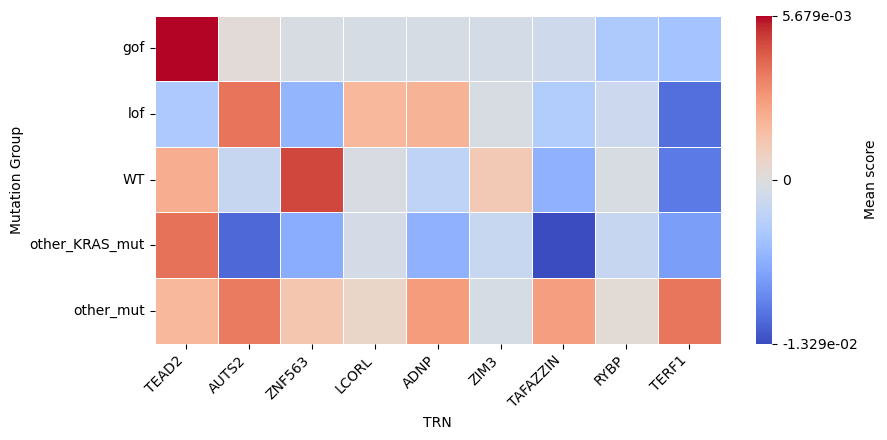

In [7]:
# Plot
# Define group order
order = ['gof', 'lof', 'WT', 'other_KRAS_mut', 'other_mut']

# Top TRNs in order
genes_to_plot = [
    "TEAD2",
    "AUTS2",
    "ZNF563",
    "LCORL",
    "ADNP",
    "ZIM3",
    "TAFAZZIN",
    "RYBP",
    "TERF1"
]

# Get TRN score columns
score_cols = [col for col in adata.obs.columns if col.endswith("_score")]

# Map gene names to matching score columns
selected_cols = []

for gene in genes_to_plot:
    matches = [
        col for col in score_cols
        if col.replace("_score", "").upper() == gene.upper()
    ]

    if len(matches) == 0:
        raise ValueError(f"No score column found for {gene}. Check column naming.")

    selected_cols.append(matches[0])

# Compute mean per mutation group × selected TRNs
heat_sel = (
    adata.obs
    .groupby("mut")[selected_cols]
    .mean()
    .reindex(order)
)

# Clean column names
heat_sel.columns = [c.replace("_score", "") for c in heat_sel.columns]

# Plot heatmap
plt.figure(figsize=(9, 4.5))

vmin = heat_sel.values.min()
vmax = heat_sel.values.max()

norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)

ax = sns.heatmap(
    heat_sel,
    cmap="coolwarm",
    norm=norm,
    annot=False,
    linewidths=0.5,
    cbar_kws={
        "label": "Mean score",
        "ticks": [vmin, 0, vmax],
    },
)

cbar = ax.collections[0].colorbar
cbar.set_ticklabels([
    f"{vmin:.3e}",
    "0",
    f"{vmax:.3e}",
])

# Set axes labels
plt.xlabel("TRN")
plt.ylabel("Mutation Group")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

# Show plot
plt.tight_layout()
plt.show()